# 09. 레짐별 Q 조정 포트폴리오 — Regime-Adaptive BL

## 동기

05_VolatilityPrediction 결과에서 고변동성 레짐에서 GARCH P 분류의 예측력이 떨어지는 현상 확인.

```
저변동성: GARCH IC 0.5631  Baseline IC 0.5122  차이 +0.051  GARCH 우위 73.3%
중간    : GARCH IC 0.5864  Baseline IC 0.5727  차이 +0.014  GARCH 우위 55.0%
고변동성: GARCH IC 0.6130  Baseline IC 0.6191  차이 -0.006  GARCH 우위 45.0%  ← 역전
```

## 해결책: Q를 레짐에 따라 동적으로 조정

P(뷰 행렬)는 GARCH 그대로 유지하되, BL 조정 강도(Q)를 레짐에 따라 다르게 적용.
고변동성에서 Q→0이면 BL이 CAPM으로 수렴하여 P 오분류의 피해를 차단.

| 레짐 | Q 설정 | 근거 |
|------|--------|------|
| 저변동성 | Q_OPTIMAL (0.003) | GARCH 예측력 최고 → 풀 강도 |
| 중간 | Q_OPTIMAL × Q_MID_SCALE | 부분 신뢰 |
| 고변동성 | Q_HIGH_VOL (0.0) | GARCH 우위 소멸 → CAPM 수렴 |

## 파라미터 표

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 스케일 파라미터 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `Q_OPTIMAL` | 05 자동 로드 | 저변동성 레짐 Q |
| `Q_MID_SCALE` | 0.5 | 중간 레짐 Q 배율 |
| `Q_HIGH_VOL` | 0.0 | 고변동성 레짐 Q |
| 레짐 기준 | SPY 12개월 롤링 변동성 expanding 분위수 | look-ahead 방지 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '09_Regime_Q_Portfolio'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 고정 파라미터 ────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2011-01-01'

# ── 레짐별 Q 파라미터 ────────────────────────────────────────
Q_MID_SCALE  = 0.5   # 중간 레짐: Q_OPTIMAL × 0.5
Q_HIGH_VOL   = 0.0   # 고변동성 레짐: BL 조정 없이 CAPM 수렴

# ── 최적 Q: 06_Q_Sensitivity 결과에서 자동 로드 ─────────────
STATS_05 = BASE_DIR / 'outputs' / '06_Q_Sensitivity' / 'q_sensitivity_stats.csv'
if STATS_05.exists():
    _s  = pd.read_csv(STATS_05, index_col='label')
    _bl = _s.drop(index=['CAPM', 'SPY'], errors='ignore')
    Q_OPTIMAL = float(_bl['sharpe'].idxmax().split('=')[1])
    print(f'05 결과 자동 로드 → Q_OPTIMAL = {Q_OPTIMAL}')
else:
    Q_OPTIMAL = 0.003
    print(f'05 결과 없음 → 기본값 사용: Q_OPTIMAL = {Q_OPTIMAL}')

Q_LOW_VOL = Q_OPTIMAL                   # 저변동성: 풀 강도
Q_MID_VOL = Q_OPTIMAL * Q_MID_SCALE    # 중간: 절반 강도

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '05_VolatilityPrediction.ipynb 먼저 실행하세요'
vol_pred_pivot = (pd.read_csv(PRED_PATH, parse_dates=['date'])
                    .set_index(['date', 'ticker'])['vol_pred']
                    .unstack('ticker'))

print(f'패널: {panel.shape}')
print(f'기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol: {vol_pred_pivot.shape}')
print()
print(f'레짐별 Q 설정:')
print(f'  저변동성 → Q = {Q_LOW_VOL:.4f}  (월 {Q_LOW_VOL*100:.2f}%)')
print(f'  중간     → Q = {Q_MID_VOL:.4f}  (월 {Q_MID_VOL*100:.2f}%)')
print(f'  고변동성 → Q = {Q_HIGH_VOL:.4f}  (월 {Q_HIGH_VOL*100:.2f}% — CAPM 수렴)')

05 결과 자동 로드 → Q_OPTIMAL = 0.002
패널: (108135, 11)
기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol: (180, 610)

레짐별 Q 설정:
  저변동성 → Q = 0.0020  (월 0.20%)
  중간     → Q = 0.0010  (월 0.10%)
  고변동성 → Q = 0.0000  (월 0.00% — CAPM 수렴)


# Black-Litterman 구성 함수

# 레짐 정의 — SPY 12개월 롤링 변동성

look-ahead bias를 막기 위해 **expanding 분위수**를 사용.
각 시점 t에서 t까지 누적된 rolling vol 분포의 33·67 퍼센타일을 임계값으로 사용.

레짐 분포 (2011~2025):
중간      96
고변동성    60
저변동성    24

Expanding 임계값 (최종 시점):
  q33 = 0.1011  (연환산 변동성 10.1% 이하 → 저변동성)
  q67 = 0.1520  (연환산 변동성 15.2% 이상 → 고변동성)


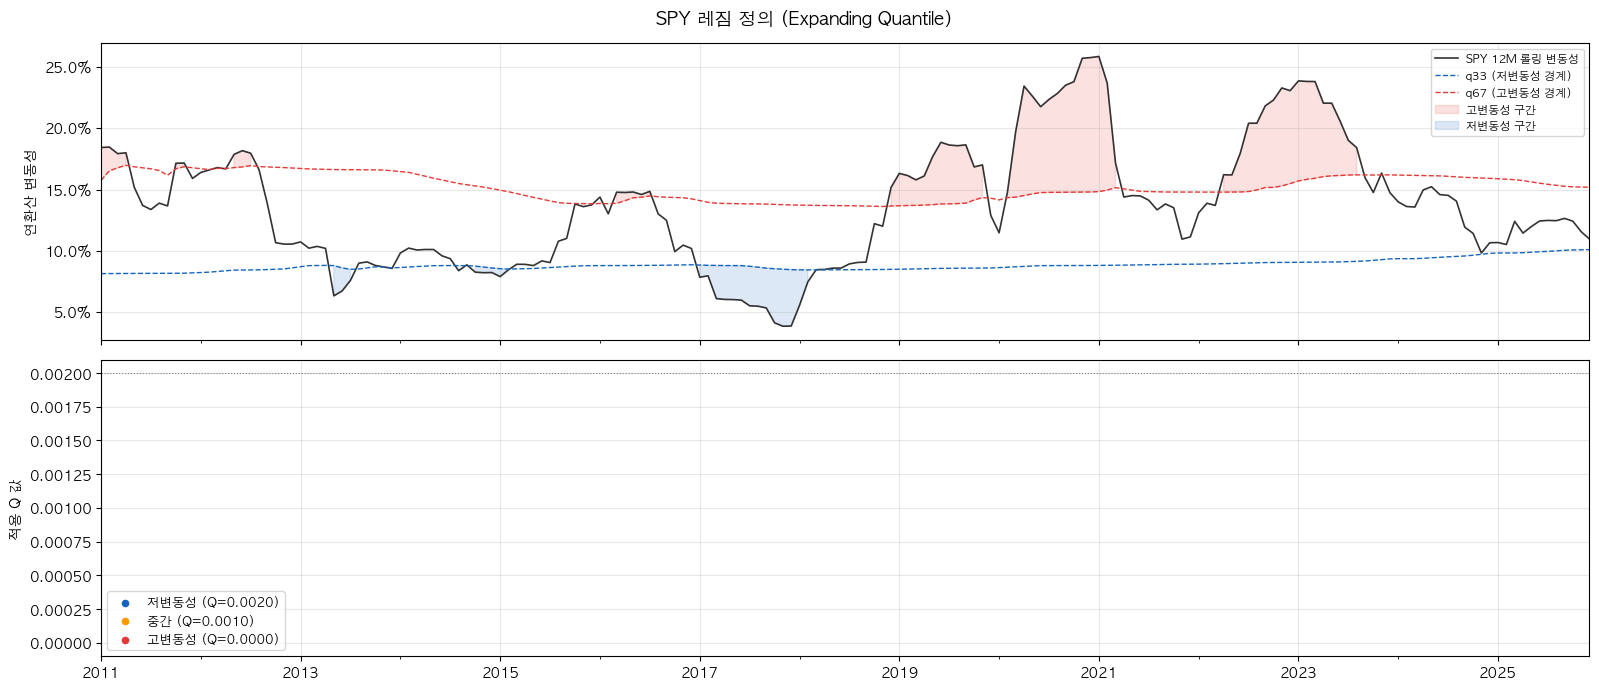

In [3]:
# SPY 12개월 롤링 변동성 (연환산)
spy_roll_vol = spy_series.rolling(12).std() * np.sqrt(12)

# Expanding 분위수 — look-ahead bias 방지
q33_exp = spy_roll_vol.expanding(min_periods=24).quantile(0.33)
q67_exp = spy_roll_vol.expanding(min_periods=24).quantile(0.67)

# 레짐 분류 (pred_dates 구간)
spy_roll_pred = spy_roll_vol.reindex(pred_dates)
q33_pred      = q33_exp.reindex(pred_dates)
q67_pred      = q67_exp.reindex(pred_dates)

regime_series = pd.Series('중간', index=pred_dates)
regime_series[spy_roll_pred <= q33_pred] = '저변동성'
regime_series[spy_roll_pred >= q67_pred] = '고변동성'

print('레짐 분포 (2011~2025):')
print(regime_series.value_counts().to_string())
print()
print('Expanding 임계값 (최종 시점):')
print(f'  q33 = {q33_pred.iloc[-1]:.4f}  (연환산 변동성 {q33_pred.iloc[-1]*100:.1f}% 이하 → 저변동성)')
print(f'  q67 = {q67_pred.iloc[-1]:.4f}  (연환산 변동성 {q67_pred.iloc[-1]*100:.1f}% 이상 → 고변동성)')

# 레짐 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('SPY 레짐 정의 (Expanding Quantile)', fontsize=13, fontweight='bold')

ax = axes[0]
spy_roll_pred.plot(ax=ax, color='#333333', linewidth=1.2, label='SPY 12M 롤링 변동성')
q33_pred.plot(ax=ax, color='#1565C0', linestyle='--', linewidth=1.0, label='q33 (저변동성 경계)')
q67_pred.plot(ax=ax, color='#E53935', linestyle='--', linewidth=1.0, label='q67 (고변동성 경계)')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred >= q67_pred),
                q67_pred, alpha=0.15, color='#E53935', label='고변동성 구간')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred <= q33_pred),
                q33_pred, alpha=0.15, color='#1565C0', label='저변동성 구간')
ax.set_ylabel('연환산 변동성')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
q_map = {'저변동성': Q_LOW_VOL, '중간': Q_MID_VOL, '고변동성': Q_HIGH_VOL}
q_regime_ts = regime_series.map(q_map)
color_map   = {'저변동성': '#1565C0', '중간': '#FF9800', '고변동성': '#E53935'}
for reg, color in color_map.items():
    mask = regime_series == reg
    ax.scatter(pred_dates[mask], q_regime_ts[mask], color=color, s=20, label=f'{reg} (Q={q_map[reg]:.4f})', zorder=3)
ax.set_ylabel('적용 Q 값')
ax.set_xlabel('')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(Q_OPTIMAL, color='gray', linestyle=':', linewidth=0.8, label='Q_OPTIMAL')

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_definition.png', dpi=150, bbox_inches='tight')
plt.show()

# Walk-forward 백테스트

동일한 루프에서 두 전략을 동시에 계산하여 공정하게 비교.
- **Regime-Q**: 레짐에 따라 Q를 동적으로 설정
- **Fixed-Q**: Q = Q_OPTIMAL 항상 고정 (비교 기준)
- **CAPM**: BL 없이 π만으로 최적화
- **SPY**: 시장 지수

In [4]:
regime_records = []   # Regime-Q 전략
fixed_records  = []   # Fixed-Q 비교군
capm_records   = []   # CAPM 벤치마크
spy_records    = []   # SPY 벤치마크
q_log          = []   # 매월 Q 값 기록
weight_records = []   # Fixed-Q 월별 포트폴리오 비중

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates) - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # GARCH vol 적용
        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=month_df.index.tolist())
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        # ── 레짐 판단 ──────────────────────────────────────────
        regime   = regime_series.get(pred_date, '중간')
        q_regime = q_map[regime]

        # ── Regime-Q 전략 ──────────────────────────────────────
        mu_regime = black_litterman(pi, Sigma, P, q_regime, omega, TAU)
        w_regime  = optimize_portfolio(mu_regime, Sigma, lam)
        regime_records.append({'date': pred_date, 'ret': float(w_regime @ actual_ret),
                                'regime': regime, 'q_used': q_regime})

        # ── Fixed-Q 전략 (비교 기준) ──────────────────────────
        mu_fixed = black_litterman(pi, Sigma, P, Q_OPTIMAL, omega, TAU)
        w_fixed  = optimize_portfolio(mu_fixed, Sigma, lam)
        fixed_records.append({'date': pred_date, 'ret': float(w_fixed @ actual_ret)})

        # 포트폴리오 구성 저장 (Fixed-Q)
        low_risk_set = set(P[P > 0].index)
        for t, w in w_fixed.items():
            if w > 1e-6:
                weight_records.append({
                    'date'       : pred_date,
                    'ticker'     : t,
                    'weight'     : float(w),
                    'vol'        : float(month_df.loc[t, 'vol_use']) if t in month_df.index else np.nan,
                    'is_low_risk': t in low_risk_set,
                })

        # ── CAPM 벤치마크 ──────────────────────────────────────
        w_capm = optimize_portfolio(pi, Sigma, lam)
        capm_records.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_records.append({'date': pred_date, 'ret': r_spy})

        q_log.append({'date': pred_date, 'q_used': q_regime, 'regime': regime})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# DataFrame 변환
regime_df  = pd.DataFrame(regime_records).set_index('date')
ret_regime = regime_df['ret']
ret_fixed  = pd.DataFrame(fixed_records).set_index('date')['ret']
ret_capm   = pd.DataFrame(capm_records).set_index('date')['ret']
ret_spy    = pd.DataFrame(spy_records).set_index('date')['ret']
q_df       = pd.DataFrame(q_log).set_index('date')
weights_df = pd.DataFrame(weight_records)

print(f'\n완료: {len(ret_regime)}개월')
print('레짐별 월수:', q_df['regime'].value_counts().to_dict())
print(f'포트폴리오 비중 기록: {len(weights_df)}건 ({weights_df["date"].nunique()}개월)')

Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료: 180개월
레짐별 월수: {'중간': 96, '고변동성': 60, '저변동성': 24}
포트폴리오 비중 기록: 33328건 (180개월)


# 성과 분석

In [5]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

stats_df = pd.DataFrame([
    performance(ret_regime, rf_monthly, f'Regime-Q'),
    performance(ret_fixed, rf_monthly,  f'Fixed-Q (Q={Q_OPTIMAL})'),
    performance(ret_capm, rf_monthly,   'CAPM'),
    performance(ret_spy, rf_monthly,    'SPY'),
]).set_index('label')

disp = stats_df.copy()
for col in ['연환산수익률', '연환산변동성', '누적수익률', 'MDD', '월별승률']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['Sharpe', 'Calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)

print('=' * 70)
print(f'성과 비교 ({ret_regime.index[0].date()} ~ {ret_regime.index[-1].date()})')
print('=' * 70)
print(disp.to_string())

regime_sharpe = stats_df.loc['Regime-Q', 'Sharpe']
fixed_sharpe  = stats_df.loc[f'Fixed-Q (Q={Q_OPTIMAL})', 'Sharpe']
capm_sharpe   = stats_df.loc['CAPM', 'Sharpe']
spy_sharpe    = stats_df.loc['SPY',  'Sharpe']

print()
print(f'Regime-Q vs Fixed-Q: Sharpe {regime_sharpe - fixed_sharpe:+.3f}  '
      f'MDD {stats_df.loc["Regime-Q","MDD"] - stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})","MDD"]:+.2%}')
print(f'Regime-Q vs CAPM:    Sharpe {regime_sharpe - capm_sharpe:+.3f}')
print(f'Regime-Q vs SPY:     Sharpe {regime_sharpe - spy_sharpe:+.3f}')

# 저장
stats_df.to_csv(OUT_DIR / 'regime_q_stats.csv')
print(f'\n저장: {OUT_DIR}/')

성과 비교 (2011-01-31 ~ 2025-12-31)
                   연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD    월별승률
label                                                                    
Regime-Q           12.66%  12.30%  0.913  0.634  491.16%  -19.96%  68.33%
Fixed-Q (Q=0.002)  12.58%  11.94%  0.934  0.653  488.40%  -19.28%  67.78%
CAPM               13.03%  14.16%  0.820  0.580  502.53%  -22.46%  67.22%
SPY                14.03%  14.06%  0.898  0.586     nan%  -23.93%  68.89%

Regime-Q vs Fixed-Q: Sharpe -0.021  MDD -0.68%
Regime-Q vs CAPM:    Sharpe +0.093
Regime-Q vs SPY:     Sharpe +0.014

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/09_Regime_Q_Portfolio/


# 시각화 — 전략 비교

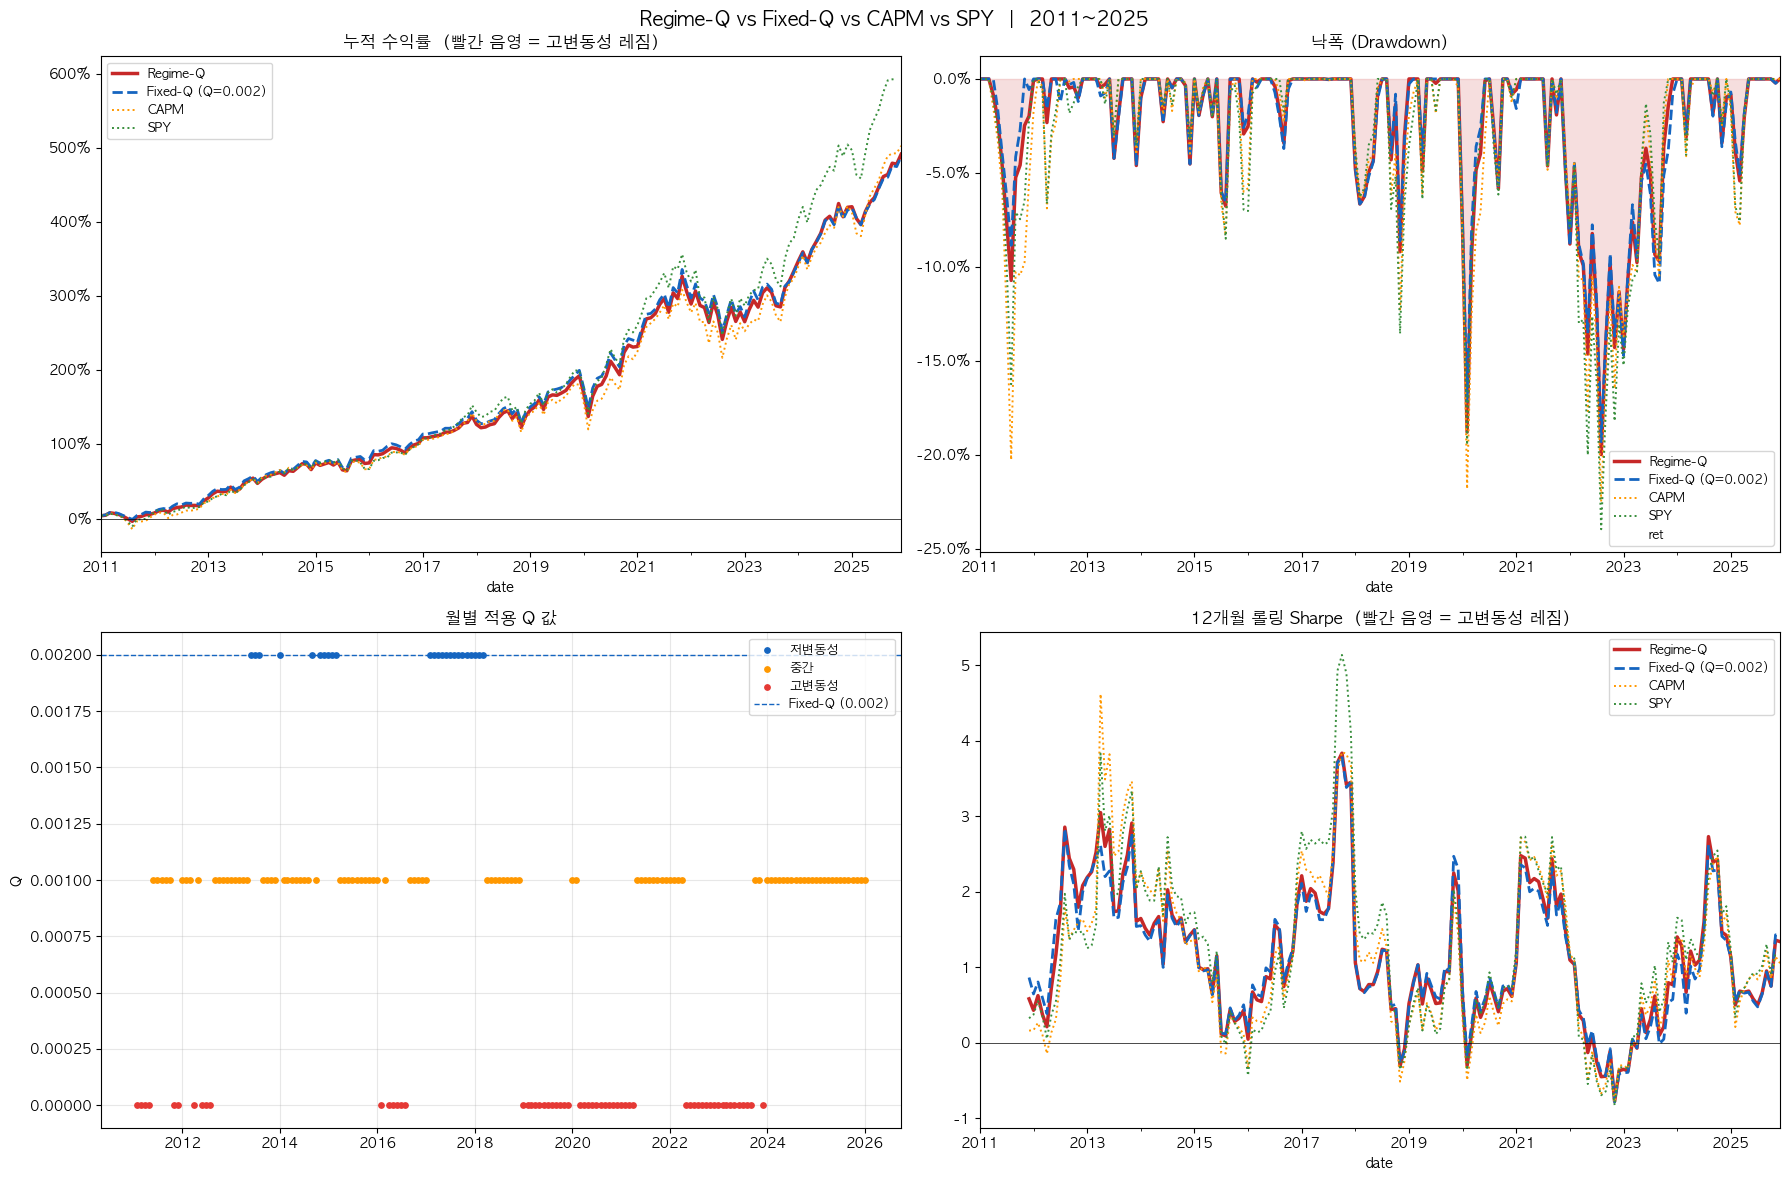

In [6]:
palette = {
    'Regime-Q':          ('#C62828', 2.5, '-'),
    f'Fixed-Q (Q={Q_OPTIMAL})': ('#1565C0', 2.0, '--'),
    'CAPM':              ('#FF9800', 1.4, ':'),
    'SPY':               ('#388E3C', 1.4, ':'),
}
ret_map = {
    'Regime-Q':          ret_regime,
    f'Fixed-Q (Q={Q_OPTIMAL})': ret_fixed,
    'CAPM':              ret_capm,
    'SPY':               ret_spy,
}

# 고변동성 구간 음영 (시각화 보조)
high_vol_mask = q_df['regime'] == '고변동성'
high_vol_dates = q_df.index[high_vol_mask]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Regime-Q vs Fixed-Q vs CAPM vs SPY  |  2011~2025', fontsize=14, fontweight='bold')

# ① 누적 수익률
ax = axes[0, 0]
shade_high_vol(ax, high_vol_dates)
for name, (color, lw, ls) in palette.items():
    cum = (1 + ret_map[name]).cumprod() - 1
    cum.plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.set_title('누적 수익률  (빨간 음영 = 고변동성 레짐)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# ② 낙폭
ax = axes[0, 1]
shade_high_vol(ax, high_vol_dates)
for name, (color, lw, ls) in palette.items():
    drawdown(ret_map[name]).plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
drawdown(ret_regime).plot(ax=ax, color='#C62828', linewidth=0)  # fill용
ax.fill_between(ret_regime.index, drawdown(ret_regime), 0, alpha=0.15, color='#C62828')
ax.set_title('낙폭 (Drawdown)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

# ③ 레짐별 적용 Q 시계열
ax = axes[1, 0]
for reg, color in color_map.items():
    mask = q_df['regime'] == reg
    ax.scatter(q_df.index[mask], q_df['q_used'][mask],
               color=color, s=15, label=reg, zorder=3)
ax.axhline(Q_OPTIMAL, color='#1565C0', linestyle='--', linewidth=1.0,
           label=f'Fixed-Q ({Q_OPTIMAL})')
ax.set_title('월별 적용 Q 값')
ax.set_ylabel('Q')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ④ 12개월 롤링 Sharpe
ax = axes[1, 1]
shade_high_vol(ax, high_vol_dates)
rf_roll = rf_monthly.reindex(ret_regime.index).fillna(0)

for name, (color, lw, ls) in palette.items():
    rf_r = rf_monthly.reindex(ret_map[name].index).fillna(0)
    rolling_sharpe(ret_map[name], rf_r).plot(
        ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('12개월 롤링 Sharpe  (빨간 음영 = 고변동성 레짐)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 레짐별 성과 분해

Regime-Q와 Fixed-Q의 차이가 어느 레짐에서 발생하는지 확인.

In [7]:
print('=' * 65)
print('레짐별 Regime-Q vs Fixed-Q 성과 비교')
print('=' * 65)

regime_by_month = q_df['regime'].reindex(ret_regime.index)

rows = []
for reg in ['저변동성', '중간', '고변동성']:
    mask = regime_by_month == reg
    n = mask.sum()
    if n == 0:
        continue

    r_reg = ret_regime[mask]
    r_fix = ret_fixed[mask]
    rf_sub = rf_monthly.reindex(r_reg.index).fillna(0)

    def sub_stats(ret, rf):
        exc = ret - rf
        sharpe = exc.mean() / exc.std() * ANN if exc.std() > 0 else np.nan
        return ret.mean() * 12, sharpe, (ret > 0).mean()

    ann_r, sh_r, hit_r = sub_stats(r_reg, rf_sub)
    ann_f, sh_f, hit_f = sub_stats(r_fix, rf_sub)

    q_applied = q_map[reg]
    rows.append({
        '레짐': reg,
        '개월수': n,
        '적용Q': q_applied,
        'RegimeQ 연수익': f'{ann_r:.2%}',
        'FixedQ 연수익':  f'{ann_f:.2%}',
        'RegimeQ Sharpe': f'{sh_r:.3f}',
        'FixedQ Sharpe':  f'{sh_f:.3f}',
        'Sharpe 차이':    f'{sh_r - sh_f:+.3f}',
    })

breakdown = pd.DataFrame(rows).set_index('레짐')
print(breakdown.to_string())

print()
print('[해석]')
for _, row in breakdown.iterrows():
    diff = float(row['Sharpe 차이'])
    if diff > 0.02:
        print(f'  {_}: Regime-Q가 Sharpe {diff:+.3f} 우위 (Q={row["적용Q"]} 조정 효과)')
    elif diff < -0.02:
        print(f'  {_}: Fixed-Q가 Sharpe {-diff:.3f} 우위 (Q 조정이 역효과)')
    else:
        print(f'  {_}: 두 전략 성과 유사 (Sharpe 차이 미미)')

레짐별 Regime-Q vs Fixed-Q 성과 비교
      개월수    적용Q RegimeQ 연수익 FixedQ 연수익 RegimeQ Sharpe FixedQ Sharpe Sharpe 차이
레짐                                                                            
저변동성   24  0.002       3.81%      3.81%          0.326         0.326    +0.000
중간     96  0.001      12.01%     12.09%          0.934         0.956    -0.022
고변동성   60  0.000      17.24%     16.87%          1.066         1.094    -0.028

[해석]
  저변동성: 두 전략 성과 유사 (Sharpe 차이 미미)
  중간: Fixed-Q가 Sharpe 0.022 우위 (Q 조정이 역효과)
  고변동성: Fixed-Q가 Sharpe 0.028 우위 (Q 조정이 역효과)


# 레짐 전이 혼동행렬

현재 레짐(t)이 다음 달 레짐(t+1)을 얼마나 정확히 예측하는지 확인.  
Regime-Q 전략은 현재 레짐을 보고 다음달 Q를 결정하므로, **레짐 지속성**이 높을수록 전략 유효성이 높다.

| 용어 | 정의 |
|------|---------|
| 정확도 | 현재 레짐 = 다음달 레짐인 비율 (대각 합계 / 전체) |
| 지속률 | 각 레짐별로 다음달 동일 레짐 유지 비율 (행 대각 / 행 합계) |
| 전이 확률 | 현재 레짐에서 다음달 각 레짐으로 넘어갈 확률 (행 합계 = 1.0) |

전체 레짐 예측 정확도: 83.8%  (현재 레짐 → 다음달 레짐)

─────────────────────────────────────────────
레짐별 지속률 (현재 레짐 → 같은 레짐 유지)
─────────────────────────────────────────────
  저변동성  : 19/24개월  (79.2%)
  중간    : 81/95개월  (85.3%)
  고변동성  : 50/60개월  (83.3%)

=== 레짐 전이 횟수 행렬 ===
다음달 레짐 (t+1)  저변동성  중간  고변동성
현재 레짐 (t)                   
저변동성            19   5     0
중간               5  81     9
고변동성             0  10    50

=== 레짐 전이 확률 행렬 (행 합 = 1.0) ===
다음달 레짐 (t+1)   저변동성     중간   고변동성
현재 레짐 (t)                        
저변동성          0.792  0.208  0.000
중간            0.053  0.853  0.095
고변동성          0.000  0.167  0.833

=== 분류 리포트 ===
              precision    recall  f1-score   support

        저변동성       0.85      0.83      0.84        60
          중간       0.79      0.79      0.79        24
        고변동성       0.84      0.85      0.85        95

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       

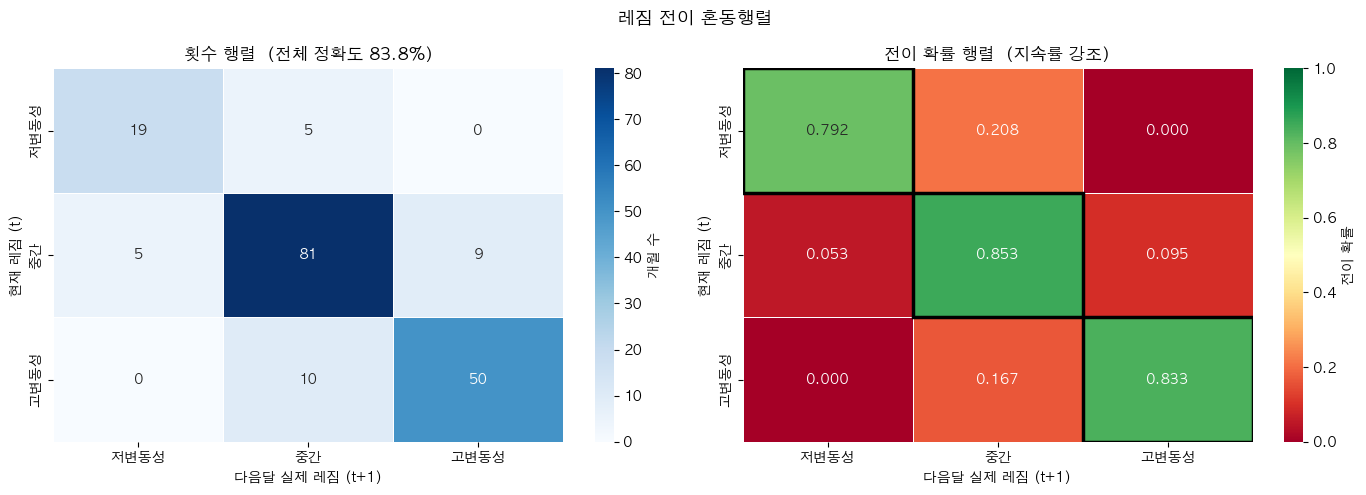

───────────────────────────────────────────────────────
[해석]
  저변동성: 지속률 79.2% → Q=0.002 설정 근거 보통
  중간: 지속률 85.3% → Q=0.001 설정 근거 강함
  고변동성: 지속률 83.3% → Q=0.0 설정 근거 강함


In [8]:
# ── 레짐 전이 혼동행렬 ──────────────────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

regime_labels_ord = ['저변동성', '중간', '고변동성']

curr_regime     = q_df['regime']
next_regime     = curr_regime.shift(-1).dropna()
curr_regime_aln = curr_regime.reindex(next_regime.index)

cm = confusion_matrix(curr_regime_aln, next_regime, labels=regime_labels_ord)
cm_df   = pd.DataFrame(cm, index=regime_labels_ord, columns=regime_labels_ord)
cm_df.index.name   = '현재 레짐 (t)'
cm_df.columns.name = '다음달 레짐 (t+1)'
prob_df = cm_df.div(cm_df.sum(axis=1), axis=0)

acc = accuracy_score(curr_regime_aln, next_regime)
print(f'전체 레짐 예측 정확도: {acc:.1%}  (현재 레짐 → 다음달 레짐)')
print()
print('─' * 45)
print('레짐별 지속률 (현재 레짐 → 같은 레짐 유지)')
print('─' * 45)
for lbl in regime_labels_ord:
    n_total = int(cm_df.loc[lbl].sum())
    n_stay  = int(cm_df.loc[lbl, lbl])
    print(f'  {lbl:6s}: {n_stay:2d}/{n_total}개월  ({n_stay/n_total:.1%})')
print()
print('=== 레짐 전이 횟수 행렬 ===')
print(cm_df.to_string())
print()
print('=== 레짐 전이 확률 행렬 (행 합 = 1.0) ===')
print(prob_df.round(3).to_string())
print()
print('=== 분류 리포트 ===')
print(classification_report(curr_regime_aln, next_regime, target_names=regime_labels_ord))

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('레짐 전이 혼동행렬', fontsize=13, fontweight='bold')

ax = axes[0]
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': '개월 수'})
ax.set_title(f'횟수 행렬  (전체 정확도 {acc:.1%})')
ax.set_xlabel('다음달 실제 레짐 (t+1)')
ax.set_ylabel('현재 레짐 (t)')

ax = axes[1]
sns.heatmap(prob_df.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': '전이 확률'})
# 대각선 강조
for j in range(len(regime_labels_ord)):
    ax.add_patch(plt.Rectangle((j, j), 1, 1, fill=False,
                                edgecolor='black', lw=2.5))
ax.set_title('전이 확률 행렬  (지속률 강조)')
ax.set_xlabel('다음달 실제 레짐 (t+1)')
ax.set_ylabel('현재 레짐 (t)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('─' * 55)
print('[해석]')
for lbl in regime_labels_ord:
    stay = prob_df.loc[lbl, lbl]
    q_lbl = q_map.get(lbl, '?')
    if stay >= 0.80:
        print(f'  {lbl}: 지속률 {stay:.1%} → Q={q_lbl} 설정 근거 강함')
    elif stay >= 0.65:
        print(f'  {lbl}: 지속률 {stay:.1%} → Q={q_lbl} 설정 근거 보통')
    else:
        print(f'  {lbl}: 지속률 {stay:.1%} → 레짐 전환 잦음, Q 설정 신뢰도 낮음')


# Q_HIGH_VOL 민감도 분석

고변동성 레짐에서 Q를 0으로 완전히 끄는 것이 최선인지,
아니면 0.001~0.002 수준의 약한 뷰를 유지하는 것이 더 나은지 확인.

민감도 분석 실행 중...

Q_HIGH_VOL 민감도 — 고변동성 레짐 Q 값별 전체 성과
    Q_HIGH       연수익       변동성    Sharpe        MDD
            Q_HIGH=0.0000   12.66%   12.30%     0.913   -19.96%
            Q_HIGH=0.0010   12.57%   12.14%     0.917   -19.69%
            Q_HIGH=0.0015   12.56%   12.06%     0.923   -19.50%
  Q_HIGH=0.0020 (Fixed-Q)   12.53%   12.00%     0.925   -35.44%
  Q_HIGH=0.0020 (Fixed-Q)   12.53%   12.00%     0.925   -35.44%

★ Q_HIGH_VOL 최적값: 0.002  (Sharpe 0.925)


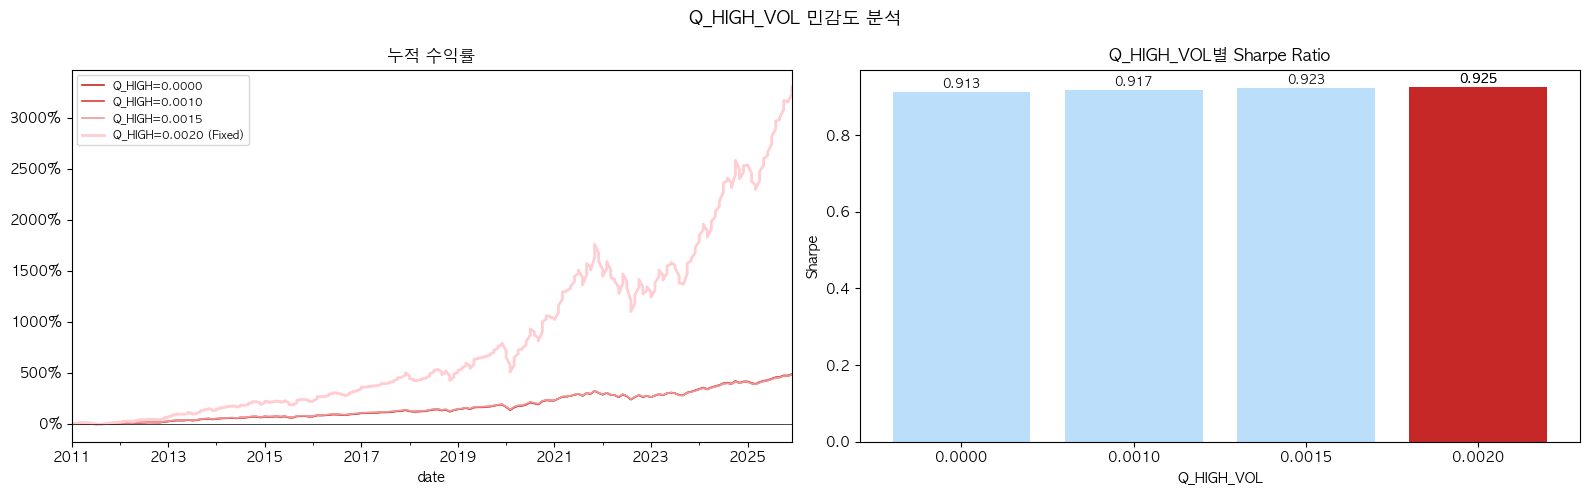

In [9]:
Q_HIGH_CANDIDATES = [0.0, 0.001, 0.0015, 0.002, Q_OPTIMAL]

sens_records = {q: [] for q in Q_HIGH_CANDIDATES}

print('민감도 분석 실행 중...')

for i, pred_date in enumerate(pred_dates):
    try:
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates) - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=month_df.index.tolist())
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        regime = regime_series.get(pred_date, '중간')

        for q_high in Q_HIGH_CANDIDATES:
            if regime == '고변동성':
                q_use = q_high
            elif regime == '저변동성':
                q_use = Q_OPTIMAL
            else:
                q_use = Q_OPTIMAL * Q_MID_SCALE

            mu_bl = black_litterman(pi, Sigma, P, q_use, omega, TAU)
            w_bl  = optimize_portfolio(mu_bl, Sigma, lam)
            sens_records[q_high].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception:
        pass

sens_ret = {q: pd.DataFrame(v).set_index('date')['ret'] for q, v in sens_records.items()}

# 성과 요약
print()
print('=' * 60)
print('Q_HIGH_VOL 민감도 — 고변동성 레짐 Q 값별 전체 성과')
print('=' * 60)
print(f'{"Q_HIGH":>10}  {"연수익":>8}  {"변동성":>8}  {"Sharpe":>8}  {"MDD":>9}')

best_sharpe = -np.inf
best_q = None
for q_high in Q_HIGH_CANDIDATES:
    ret = sens_ret[q_high]
    rf  = rf_monthly.reindex(ret.index).fillna(0)
    exc = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = exc.mean() / exc.std() * ANN
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    label = f'Q_HIGH={q_high:.4f}'
    if q_high == Q_OPTIMAL:
        label += ' (Fixed-Q)'
    star = ' ←' if sharpe > best_sharpe else ''
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_q = q_high
    print(f'{label:>25}  {ann_ret:>7.2%}  {ann_vol:>7.2%}  {sharpe:>8.3f}  {mdd:>8.2%}')

print()
print(f'★ Q_HIGH_VOL 최적값: {best_q}  (Sharpe {best_sharpe:.3f})')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q_HIGH_VOL 민감도 분석', fontsize=13, fontweight='bold')

colors_sens = ['#C62828', '#E53935', '#EF9A9A', '#FFCDD2', '#1565C0']
ax = axes[0]
for (q_high, ret), color in zip(sens_ret.items(), colors_sens):
    label = f'Q_HIGH={q_high:.4f}'
    if q_high == Q_OPTIMAL:
        label += ' (Fixed)'
    ((1 + ret).cumprod() - 1).plot(ax=ax, label=label, color=color,
                                    linewidth=2.0 if q_high == best_q else 1.2)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
q_labels = [f'{q:.4f}' for q in Q_HIGH_CANDIDATES]
sharpes_s = []
for q_high in Q_HIGH_CANDIDATES:
    ret = sens_ret[q_high]
    rf  = rf_monthly.reindex(ret.index).fillna(0)
    exc = ret - rf
    sharpes_s.append(exc.mean() / exc.std() * ANN)
bar_colors = ['#C62828' if q == best_q else '#BBDEFB' for q in Q_HIGH_CANDIDATES]
bars = ax.bar(q_labels, sharpes_s, color=bar_colors)
for bar, val in zip(bars, sharpes_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Q_HIGH_VOL별 Sharpe Ratio')
ax.set_xlabel('Q_HIGH_VOL')
ax.set_ylabel('Sharpe')

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_high_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


# 결과 저장 및 요약

In [10]:
# 결과 저장
regime_df.to_csv(OUT_DIR / 'regime_q_returns.csv')
ret_fixed.to_csv(OUT_DIR / 'fixed_q_returns.csv', header=['ret'])
q_df.to_csv(OUT_DIR / 'regime_log.csv')
breakdown.to_csv(OUT_DIR / 'regime_breakdown.csv')

print('저장 파일:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')

print()
print('=' * 60)
print('최종 요약')
print('=' * 60)
print(f'  Regime-Q  Sharpe: {stats_df.loc["Regime-Q", "Sharpe"]:.3f}')
print(f'  Fixed-Q   Sharpe: {stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})", "Sharpe"]:.3f}')
print(f'  CAPM      Sharpe: {stats_df.loc["CAPM", "Sharpe"]:.3f}')
print(f'  SPY       Sharpe: {stats_df.loc["SPY", "Sharpe"]:.3f}')
print()
print(f'  Regime-Q vs Fixed-Q: {stats_df.loc["Regime-Q","Sharpe"] - stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})","Sharpe"]:+.3f}')
print(f'  최적 Q_HIGH_VOL: {best_q}  (민감도 분석 기준)')

저장 파일:
  fixed_q_returns.csv
  portfolio_composition_eda.png
  portfolio_composition_stats.csv
  q_high_sensitivity.png
  regime_breakdown.csv
  regime_confusion_matrix.png
  regime_definition.png
  regime_log.csv
  regime_q_comparison.png
  regime_q_returns.csv
  regime_q_stats.csv

최종 요약
  Regime-Q  Sharpe: 0.913
  Fixed-Q   Sharpe: 0.934
  CAPM      Sharpe: 0.820
  SPY       Sharpe: 0.898

  Regime-Q vs Fixed-Q: -0.021
  최적 Q_HIGH_VOL: 0.002  (민감도 분석 기준)


# 포트폴리오 구성 EDA — Fixed-Q BL 전략

walk-forward 전 기간(2011~2025)에 걸쳐 BL Fixed-Q 포트폴리오의 **구성 특성**이 어떻게 변해왔는지 시계열로 분석한다.

| 지표 | 정의 | 해석 |
|------|------|------|
| 유효 종목 수 (1/HHI) | 비중 제곱합의 역수 | 클수록 분산화 |
| 상위 10종목 비중 | 상위 10개 비중 합 | 집중도 |
| 가중 평균 변동성 | Σ(w × vol) | BL이 저위험에 실제로 집중하는가 |
| 저위험 그룹 비중 | P>0 종목 비중 합 | BL 뷰 반영 정도 |
| 단일 종목 최대 비중 | max(w) | 극단 집중 위험 |

=== Fixed-Q BL 포트폴리오 구성 지표 전체 기간 평균 ===
  유효 종목 수 (1/HHI):   41.4개
  상위 10종목 비중:       36.7%
  가중 평균 변동성:       18.7% (연환산)
  저위험 그룹 비중:       70.8%
  단일 종목 최대 비중:    9.9%

=== 레짐별 비교 ===
                유효N     상위10비중      저위험비중       최대비중
-------------------------------------------------------
저변동성           39.9      37.7%      69.9%      10.8%
중간             40.0      37.4%      69.8%      10.3%
고변동성           44.3      35.2%      72.8%       9.0%


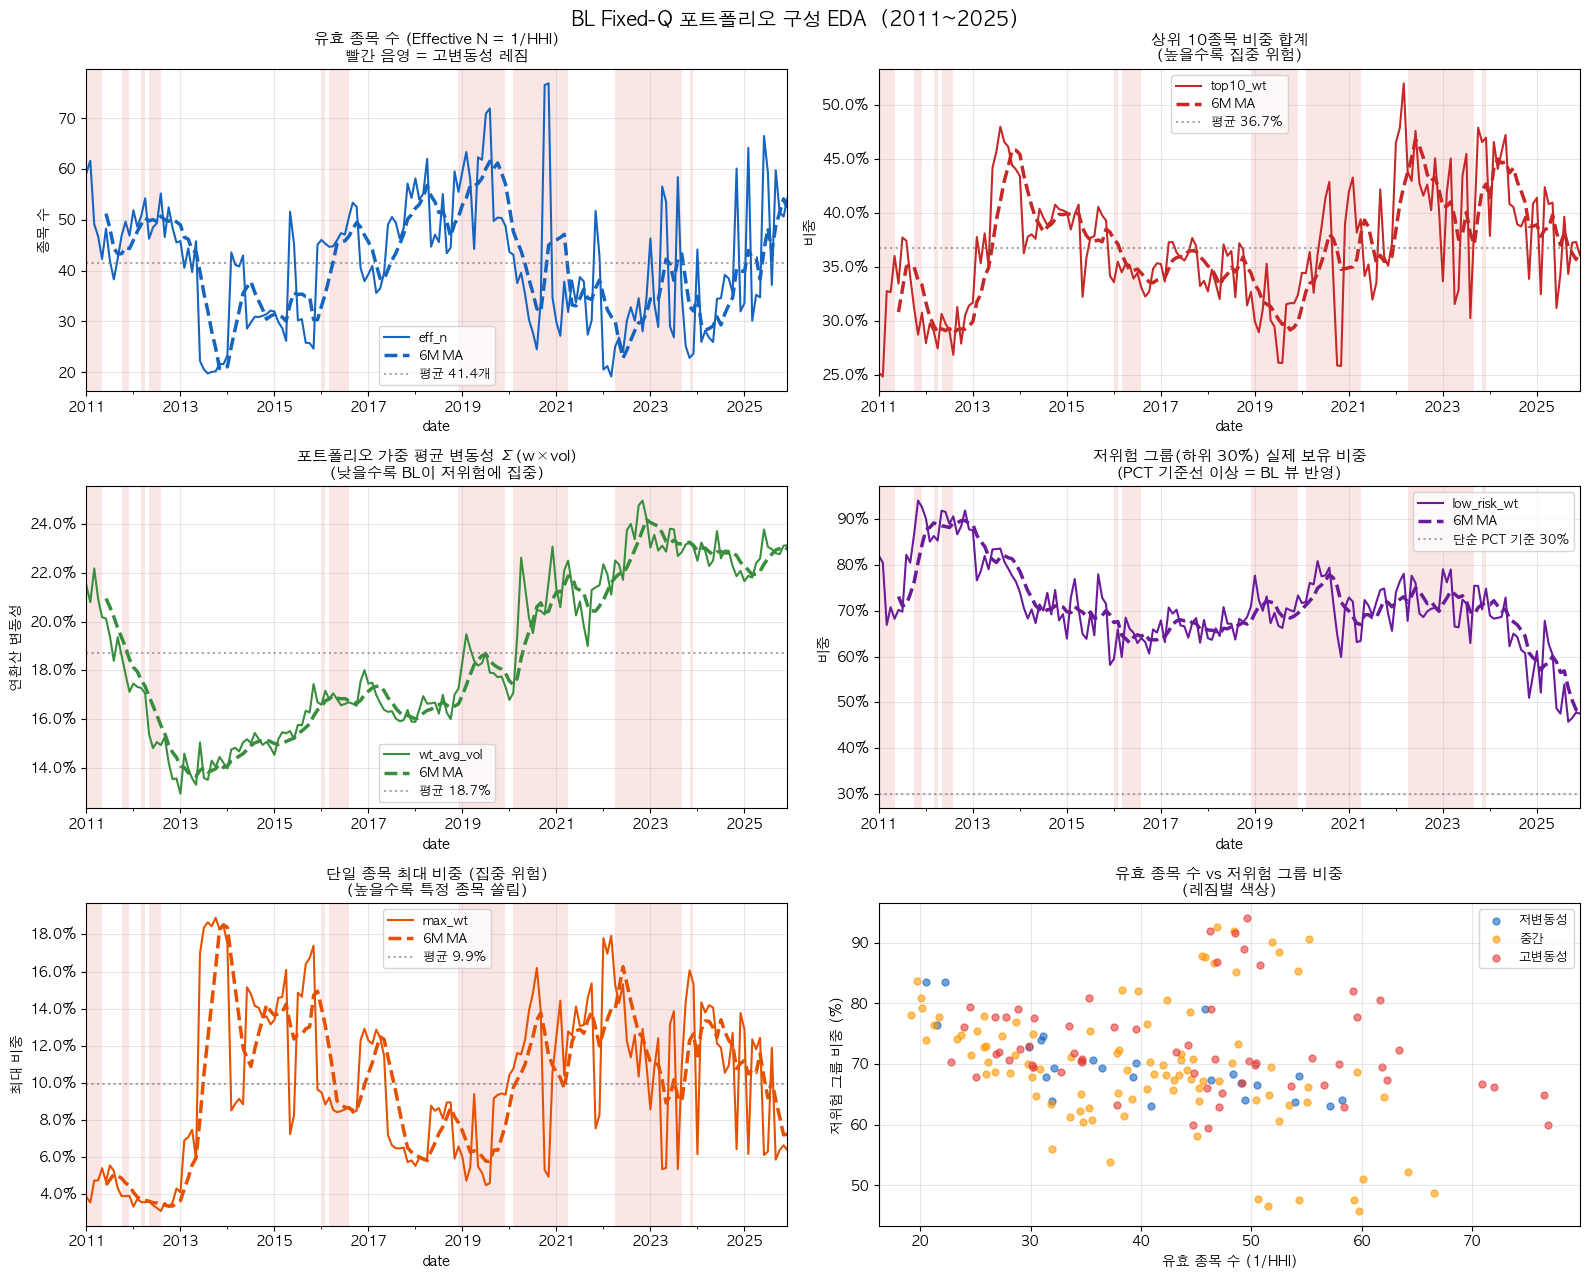


저장: portfolio_composition_eda.png, portfolio_composition_stats.csv


In [11]:
# ── 월별 포트폴리오 구성 지표 계산 ────────────────────────────
monthly_stats = []

for date, grp in weights_df.groupby('date'):
    w   = grp['weight'].values
    vol = grp['vol'].values
    low = grp['is_low_risk'].values

    hhi         = float((w ** 2).sum())
    eff_n       = 1.0 / hhi if hhi > 0 else np.nan
    top10_wt    = float(np.sort(w)[::-1][:10].sum())
    wt_avg_vol  = float((w * vol).sum()) if not np.isnan(vol).all() else np.nan
    low_wt      = float(w[low].sum())
    max_wt      = float(w.max())

    monthly_stats.append({
        'date'       : date,
        'eff_n'      : eff_n,
        'top10_wt'   : top10_wt,
        'wt_avg_vol' : wt_avg_vol,
        'low_risk_wt': low_wt,
        'max_wt'     : max_wt,
    })

ms = pd.DataFrame(monthly_stats).set_index('date')

# 레짐 정보 병합 (고변동성 음영용)
ms['regime'] = q_df['regime'].reindex(ms.index).fillna('중간')

# ── 수치 요약 ──────────────────────────────────────────────────
print('=== Fixed-Q BL 포트폴리오 구성 지표 전체 기간 평균 ===')
print(f'  유효 종목 수 (1/HHI):   {ms["eff_n"].mean():.1f}개')
print(f'  상위 10종목 비중:       {ms["top10_wt"].mean()*100:.1f}%')
print(f'  가중 평균 변동성:       {ms["wt_avg_vol"].mean()*100:.1f}% (연환산)')
print(f'  저위험 그룹 비중:       {ms["low_risk_wt"].mean()*100:.1f}%')
print(f'  단일 종목 최대 비중:    {ms["max_wt"].mean()*100:.1f}%')

print()
print('=== 레짐별 비교 ===')
print(f'{"":10} {"유효N":>8} {"상위10비중":>10} {"저위험비중":>10} {"최대비중":>10}')
print('-' * 55)
for reg in ['저변동성', '중간', '고변동성']:
    sub = ms[ms['regime'] == reg]
    if len(sub) == 0:
        continue
    print(f'{reg:10} {sub["eff_n"].mean():>8.1f} '
          f'{sub["top10_wt"].mean()*100:>9.1f}% '
          f'{sub["low_risk_wt"].mean()*100:>9.1f}% '
          f'{sub["max_wt"].mean()*100:>9.1f}%')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('BL Fixed-Q 포트폴리오 구성 EDA  (2011~2025)', fontsize=14, fontweight='bold')

# 고변동성 구간 음영 헬퍼
def shade_regime(ax, ms_df):
    in_block, start = False, None
    for d, reg in ms_df['regime'].items():
        if reg == '고변동성' and not in_block:
            start, in_block = d, True
        elif reg != '고변동성' and in_block:
            ax.axvspan(start, d, alpha=0.12, color='#E53935', linewidth=0)
            in_block = False
    if in_block:
        ax.axvspan(start, ms_df.index[-1], alpha=0.12, color='#E53935', linewidth=0)

# ① 유효 종목 수 (1/HHI)
ax = axes[0, 0]
ms['eff_n'].plot(ax=ax, color='#1565C0', linewidth=1.5)
ms['eff_n'].rolling(6).mean().plot(ax=ax, color='#1565C0', linewidth=2.5,
                                    linestyle='--', label='6M MA')
shade_regime(ax, ms)
ax.set_title('유효 종목 수 (Effective N = 1/HHI)\n빨간 음영 = 고변동성 레짐', fontsize=11)
ax.set_ylabel('종목 수')
ax.axhline(ms['eff_n'].mean(), color='gray', ls=':', alpha=0.7,
           label=f'평균 {ms["eff_n"].mean():.1f}개')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ② 상위 10종목 비중
ax = axes[0, 1]
ms['top10_wt'].plot(ax=ax, color='#C62828', linewidth=1.5)
ms['top10_wt'].rolling(6).mean().plot(ax=ax, color='#C62828', linewidth=2.5,
                                       linestyle='--', label='6M MA')
shade_regime(ax, ms)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('상위 10종목 비중 합계\n(높을수록 집중 위험)', fontsize=11)
ax.set_ylabel('비중')
ax.axhline(ms['top10_wt'].mean(), color='gray', ls=':', alpha=0.7,
           label=f'평균 {ms["top10_wt"].mean()*100:.1f}%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ③ 가중 평균 변동성
ax = axes[1, 0]
ms['wt_avg_vol'].plot(ax=ax, color='#388E3C', linewidth=1.5)
ms['wt_avg_vol'].rolling(6).mean().plot(ax=ax, color='#388E3C', linewidth=2.5,
                                         linestyle='--', label='6M MA')
shade_regime(ax, ms)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('포트폴리오 가중 평균 변동성 Σ(w×vol)\n(낮을수록 BL이 저위험에 집중)', fontsize=11)
ax.set_ylabel('연환산 변동성')
ax.axhline(ms['wt_avg_vol'].mean(), color='gray', ls=':', alpha=0.7,
           label=f'평균 {ms["wt_avg_vol"].mean()*100:.1f}%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ④ 저위험 그룹 실제 비중
ax = axes[1, 1]
ms['low_risk_wt'].plot(ax=ax, color='#6A1B9A', linewidth=1.5)
ms['low_risk_wt'].rolling(6).mean().plot(ax=ax, color='#6A1B9A', linewidth=2.5,
                                          linestyle='--', label='6M MA')
shade_regime(ax, ms)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(PCT_GROUP, color='gray', ls=':', alpha=0.7,
           label=f'단순 PCT 기준 {PCT_GROUP*100:.0f}%')
ax.set_title(f'저위험 그룹(하위 {PCT_GROUP*100:.0f}%) 실제 보유 비중\n(PCT 기준선 이상 = BL 뷰 반영)', fontsize=11)
ax.set_ylabel('비중')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ⑤ 단일 종목 최대 비중
ax = axes[2, 0]
ms['max_wt'].plot(ax=ax, color='#E65100', linewidth=1.5)
ms['max_wt'].rolling(6).mean().plot(ax=ax, color='#E65100', linewidth=2.5,
                                     linestyle='--', label='6M MA')
shade_regime(ax, ms)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('단일 종목 최대 비중 (집중 위험)\n(높을수록 특정 종목 쏠림)', fontsize=11)
ax.set_ylabel('최대 비중')
ax.axhline(ms['max_wt'].mean(), color='gray', ls=':', alpha=0.7,
           label=f'평균 {ms["max_wt"].mean()*100:.1f}%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ⑥ 지표 상관 히트맵 (레짐 색상 scatter)
ax = axes[2, 1]
color_reg = {'저변동성': '#1565C0', '중간': '#FF9800', '고변동성': '#E53935'}
for reg, col in color_reg.items():
    sub = ms[ms['regime'] == reg]
    ax.scatter(sub['eff_n'], sub['low_risk_wt'] * 100,
               color=col, alpha=0.6, s=25, label=reg)
ax.set_xlabel('유효 종목 수 (1/HHI)')
ax.set_ylabel('저위험 그룹 비중 (%)')
ax.set_title('유효 종목 수 vs 저위험 그룹 비중\n(레짐별 색상)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_composition_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# CSV 저장
ms.drop(columns='regime').to_csv(OUT_DIR / 'portfolio_composition_stats.csv')
print(f'\n저장: portfolio_composition_eda.png, portfolio_composition_stats.csv')